In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv('HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [7]:
df.shape

(1470, 35)

In [8]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [10]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

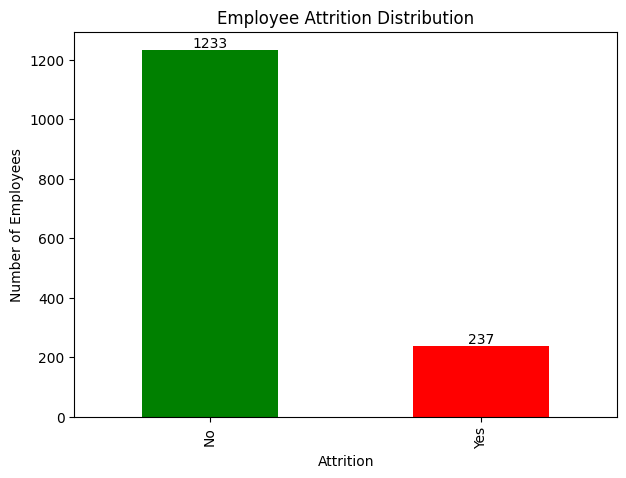

In [36]:
#Overall Attrition Rate Visualization

attrition = df['Attrition'].value_counts()
plt.figure(figsize=(7,5))
ax = attrition.plot(kind='bar', color=['green', 'red'])

for i in ax.containers:
    ax.bar_label(i)
    
plt.title('Employee Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.show()


##### The majority of people remained with the organizationwhile smaller proportion left, resulting in an overall attrition rate of approximately 16%.


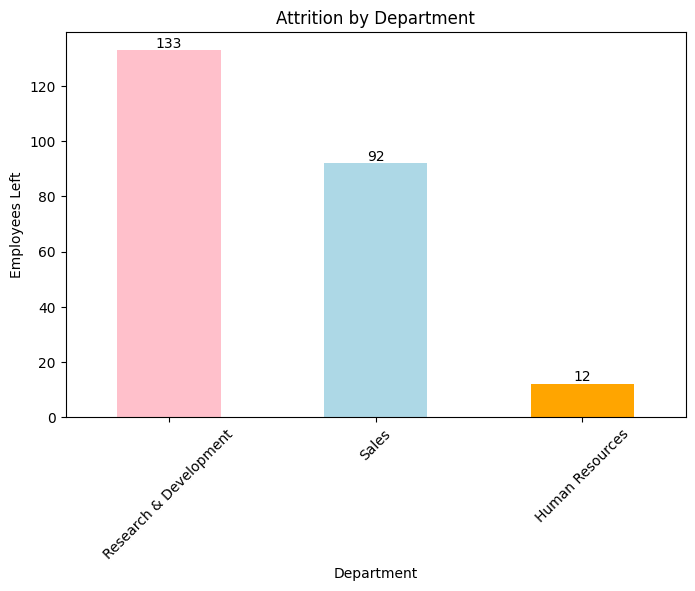

In [37]:
#Department-wise Attrition

dept_att = df.groupby('Department')['Attrition'].apply(
lambda x: (x == 'Yes').sum()).sort_values(ascending = False)

plt.figure(figsize=(8,5))
ax= dept_att.plot(kind='bar', color=['pink','lightblue','orange'])
for i in ax.containers:
    ax.bar_label(i)
    

plt.title('Attrition by Department')
plt.xlabel('Department')
plt.xticks(rotation=45)
plt.ylabel('Employees Left')
plt.show()

##### Research & Department recoreded the highest number of employee exists, followed by Sales and Human Resources.

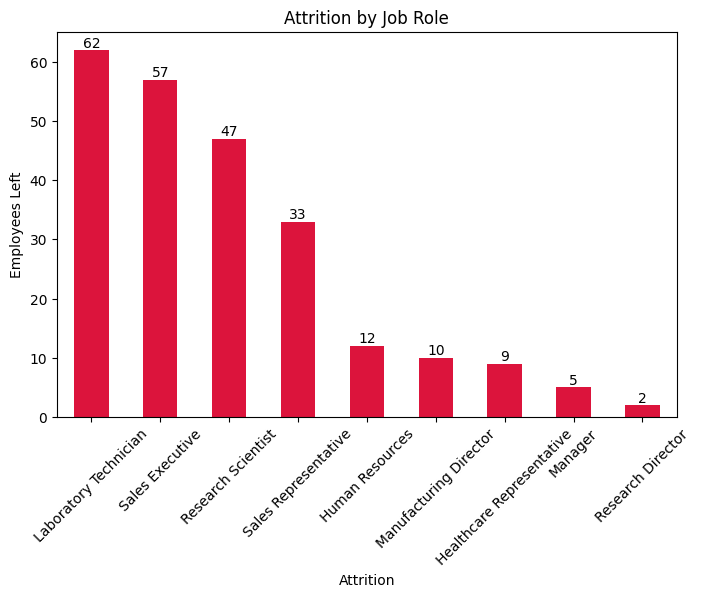

In [38]:
#Job Role Attrition

role_att = df.groupby('JobRole')['Attrition'].apply(
lambda x : (x =='Yes').sum()).sort_values(ascending = False)

plt.figure(figsize=(8,5))
ax= role_att.plot(kind ='bar', color='crimson')
for i in ax.containers:
    ax.bar_label(i)

plt.title('Attrition by Job Role')
plt.xlabel('Job Role')
plt.xticks(rotation=45)
plt.ylabel('Employees Left')

plt.show()

##### Laboratory Technician and Sales Exexutive experienced the highest attrition counts, indicating potential retention challenges in these roles.


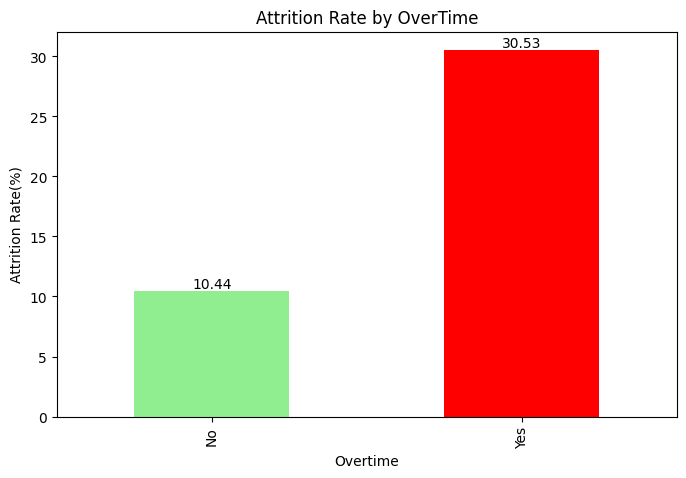

In [41]:
#OverTime vs Attrition

overtime_att = df.groupby('OverTime')['Attrition'].apply(
lambda x: ( x=='Yes').mean()*100)

plt.figure(figsize=(8,5))
ax=overtime_att.plot(kind='bar', color = ['lightgreen', 'red'])
for i in ax.containers:
    ax.bar_label(i, fmt = '%.2f')

plt.title('Attrition Rate by OverTime')
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate(%)')

plt.show()

##### Employees working overtime exhibited a significant higher attrition rate than those who did not, highlighting workload and work-life balance as key contributors to employee turnover.

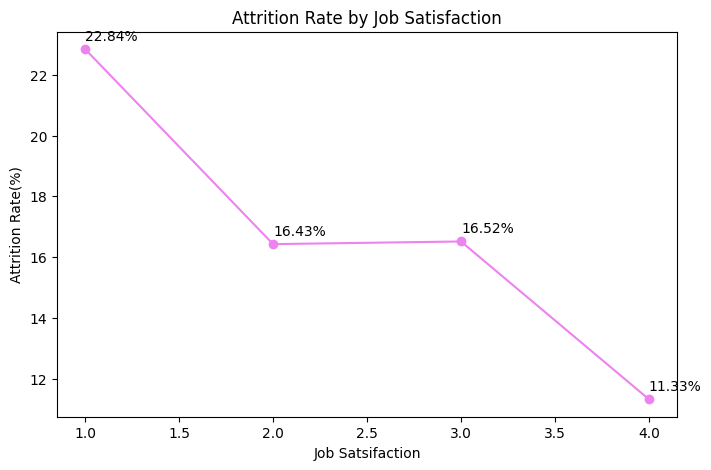

In [43]:
#Job Satisfaction vs Attrition

jobSa_att = df.groupby('JobSatisfaction')['Attrition'].apply(
lambda x: (x == 'Yes').mean()* 100)

plt.figure(figsize=(8,5))
ax= jobSa_att.plot(kind='line', marker='o', color='violet')
for x, y in enumerate(jobSa_att):
    plt.text(x+1, y+0.3, f'{y:.2f}%')

plt.title('Attrition Rate by Job Satisfaction')
plt.xlabel('Job Satsifaction')
plt.ylabel('Attrition Rate(%)')

plt.show()


##### Attrition decreases as job satsifaction increases , highlighting the importance of employee engagement and workplace satsifaction.

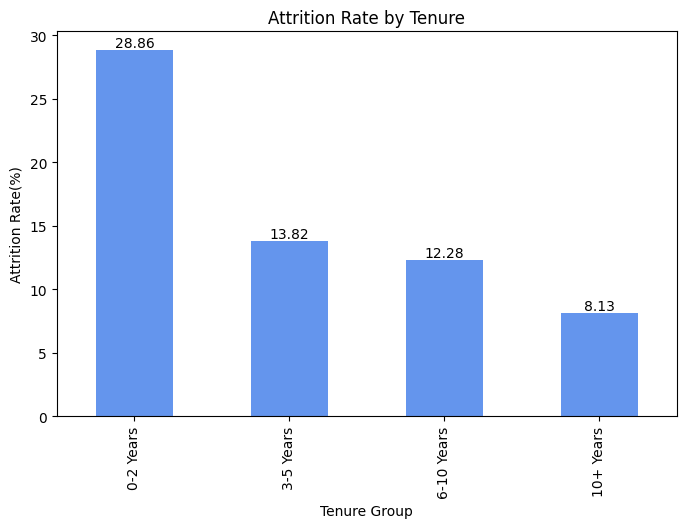

In [44]:
#Tenure vs Attrition

df['Tenure_Group'] = pd.cut(
    df['YearsAtCompany'], 
    bins=[0,2,5,10,40], 
    labels=['0-2 Years','3-5 Years','6-10 Years','10+ Years']
)

tenure_att = df.groupby('Tenure_Group')['Attrition'].apply(
lambda x: (x=='Yes').mean()*100)

plt.figure(figsize=(8,5))
ax= tenure_att.plot(kind='bar', color='cornflowerblue')
for i in ax.containers:
    ax.bar_label(i, fmt = '%.2f')

plt.title('Attrition Rate by Tenure')
plt.xlabel('Tenure Group')
plt.ylabel('Attrition Rate(%)')

plt.show()

##### Employees with less than two years of service experienced the highest attrition, indicating that turnover is concentrated among newer employees.


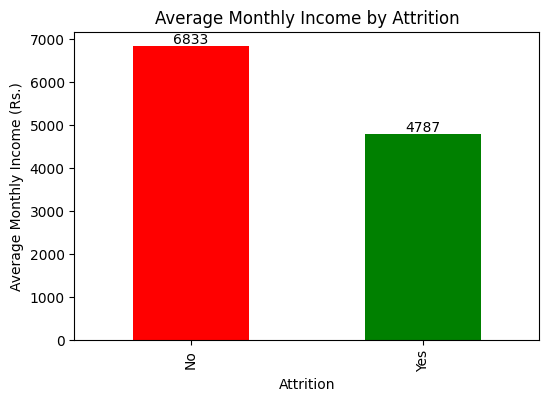

In [47]:
#Average Monthly Income by Attrition

income_att = df.groupby('Attrition')['MonthlyIncome'].mean()

ax = income_att.plot(
    kind='bar',
    color=['red','green'],
    figsize=(6,4)
)

for i in ax.containers:
    ax.bar_label(i, fmt='%.0f')

plt.title('Average Monthly Income by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Average Monthly Income (Rs.)')

plt.show()

##### Employees who left earned approximately 30% less than those who stayed, highlighting compensation as a potential driver of employee attrition.